# TP1 : Génération de variables aléatoires

## G3 SDI - Estimation Avancée

Dans ce TP, on s'intéresse à la génération de variables aléatoires, i.e., la capacité de produire des échantillons finis de variables ou vecteurs aléatoires d'une loi donnée.
* Dans un premier temps, on suppose que l'on dispose d'un générateur de loi uniforme sur $[0,1]$ (avec Numpy, il est donné par `np.random.rand`). À partir de ce générateur, le but sera de générer des échantillons d'autres lois avec des méthodes simples, notamment la méthode de la transformée inverse.
* Dans un deuxième temps, on étudiera des méthodes plus sophistiquées (acceptation-rejet, échantillonnage d'importance).

Pour chaque question, **justifier brièvement la solution puis l'implémenter**. **Comparer avec la densité théorique** à l'aide d'histogrammes ou de KDE.

### Instructions

1. Renommez votre notebook sous la forme `tp1_Nom1_Nom2.ipynb`. 

2. Votre code, ainsi que toute sortie du code, doivent être commentés !

3. Déposez votre notebook sur Moodle dans la section prévue à cet effet avant la date limite.

**Compte rendu — Ugo Roccamatisi.**


In [2]:
# Importing usual libraries
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KernelDensity

### Exercice 1 - Pour commencer : lois uniformes

**Q1**. À partir de $N$ échantillons d'une loi uniforme sur l'intervalle $[0,1]$, comment obtenir $N$ échantillons d'une loi uniforme sur l'intervalle $[a,b]$ ?

**Justification.** Si $U\sim\mathcal U[0,1]$, alors $a+(b-a)U\sim\mathcal U[a,b]$ car sa fonction de répartition vaut $(x-a)/(b-a)$ à l’intérieur de l’intervalle.

Moyenne expérimentale/théorique : 0.5115956427998446 0.5


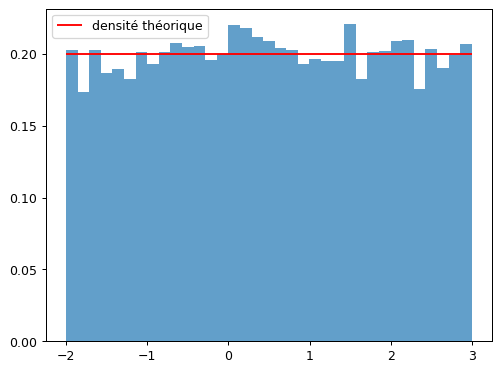

In [6]:
rng=np.random.default_rng(2025);N=10000;a,b=-2,3
U=rng.random(N);samples=a+(b-a)*U
fig,ax=plt.subplots();ax.hist(samples,bins=35,density=True,alpha=.7);ax.hlines(1/(b-a),a,b,color='r',label='densité théorique');ax.legend();plt.show()
print('Moyenne expérimentale/théorique :',samples.mean(),(a+b)/2)

**Q2**. Comment obtenir $N$ échantillons d'une loi uniforme sur le pavé $[a,b] \times [c,d]$ ?

**Justification.** Utiliser deux tirages uniformes indépendants $U,V$ et renvoyer $(a+(b-a)U,c+(d-c)V)$ ; la densité jointe vaut $1/[(b-a)(d-c)]$ sur le pavé.

Moyenne théorique : [0.5, 2.5] ; moyenne empirique : [0.46634926 2.49534671]


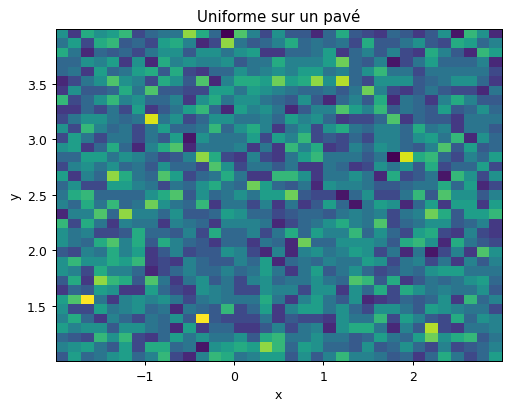

In [9]:
# Deux coordonnées uniformes indépendantes, donc densité constante sur le pavé.
c,d=1,4
points=np.column_stack((a+(b-a)*rng.random(N),c+(d-c)*rng.random(N)))
fig,ax=plt.subplots();ax.hist2d(*points.T,bins=35,cmap='viridis');ax.set(xlabel='x',ylabel='y',title='Uniforme sur un pavé');plt.show()
print('Moyenne théorique :',[(a+b)/2,(c+d)/2],'; moyenne empirique :',points.mean(axis=0))

**Q3**. À partir de $N$ échantillons de loi uniforme sur l'intervalle $[0,1]$, comment obtenir $N$ échantillons de loi uniforme discrète sur $\{1, ..., K\}$ ?

**Justification.** $J=1+\lfloor KU\rfloor$ prend chacune des valeurs $1,\dots,K$ avec probabilité $1/K$ si $U\in[0,1[$.

Fréquences des 6 modalités : [0.166 0.166 0.174 0.168 0.161 0.164]


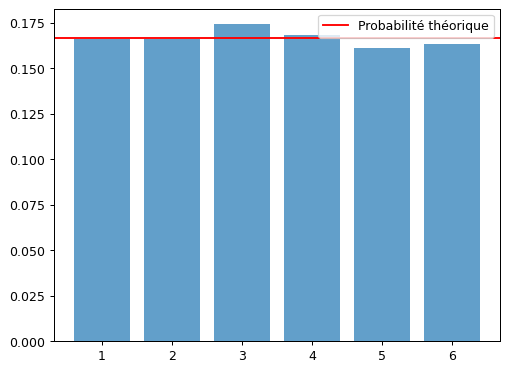

In [12]:
K=6;discrete=np.floor(K*rng.random(N)).astype(int)+1
freq=np.bincount(discrete,minlength=K+1)[1:]/N
fig,ax=plt.subplots();ax.bar(np.arange(1,K+1),freq,alpha=.7);ax.axhline(1/K,c='r',label='Probabilité théorique');ax.legend();plt.show()
print('Fréquences des 6 modalités :',np.round(freq,3))

### Exercice 2 - Méthode de la transformée inverse

Soit $X$ une variable aléatoire réelle de fonction de répartition $F$ (rappel : $F$ est une fonction croissante de $\mathbb{R}$ dans $[0,1]$, et "càdlàg", mais pas nécessairement bijective). On définit la **fonction inverse généralisée** $F^{-1}$ de $F$ par :
$$\forall~u \in [0,1],~F^{-1}(u) = \inf\{x \in \mathbb{R}, F(x) \geq u\}.$$

Cette fonction conïncide avec l'inverse classique quand $F$ est bijective (attention même si $F$ est continue elle n'est pas nécessairement bijective, il peut y avoir des plateaux). On a la proposition suivante :

Si $U$ suit la loi uniforme sur l'intervalle $[0,1]$, alors la v.a. $F^{-1}(U)$ a pour fonction de répartition $F$ (et donc la même loi que $X$).


Cela donne donc la méthode de la **transformée inverse** ; Si l'on connait explicitement la fonction $F^{-1}$, on peut simuler de n'importe quelle variable aléatoire réelle à partir d'un échantillon de loi uniforme.

**Q1**. À l'aide de cette méthode, simuler $N$ échantillons d'une loi exponentielle de paramètre $\lambda$.

**Justification.** $F(x)=1-e^{-\lambda x}$ pour $x\ge0$, donc $F^{-1}(u)=-\log(1-u)/\lambda$. Avec NumPy, `-log1p(-u)` est précis quand $u$ est petit.

Moyenne empirique/théorique : 0.5784389967804607 0.5882352941176471


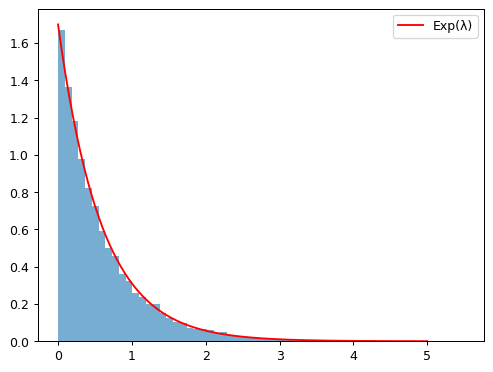

In [17]:
from scipy import stats as ss
rate=1.7;U=rng.random(N)
exponential=-np.log1p(-U)/rate
fig,ax=plt.subplots();ax.hist(exponential,bins=60,density=True,alpha=.6);t=np.linspace(0,5,300);ax.plot(t,ss.expon.pdf(t,scale=1/rate),'r',label='Exp(λ)');ax.legend();plt.show()
print('Moyenne empirique/théorique :',exponential.mean(),1/rate)

**Q2**. Quelles sont d'après vous les limitations de la méthode de la transformée inverse ?

**Réponse.** Il faut connaître ou calculer numériquement la fonction quantile, ce qui peut être difficile ; en plusieurs dimensions, la dépendance entre coordonnées exige davantage qu’une inversion marginale. L’inverse généralisée traite cependant les discontinuités et les plateaux.

### Exercice 3 - Méthode de Box-Müller

On a la proposition suivante :

Soit $R \sim \text{Exp}(1/2)$ et $\Theta \sim U([0, 2 \pi])$ deux variables aléatoires indépendantes.
    
Alors $X = \sqrt{R} \cos(\Theta)$ et $Y = \sqrt{R} \sin(\Theta)$ sont deux variables indépendantes de loi $\mathcal{N}(0,1)$.

Cette méthode est connue comme la méthode de **Box-Müller** (1958), et est l'une des méthodes de référence pour générer des variables aléatoires normales.

**Q1 (Bonus)**. Montrer la proposition.

**Démonstration (bonus).** Poser $R=r^2$ : si $R\sim\mathrm{Exp}(1/2)$, la densité du rayon est $r e^{-r^2/2}$ sur $r>0$. Comme l’angle est indépendant et uniforme sur $[0,2\pi]$, la densité conjointe en polaires vaut $r e^{-r^2/2}/(2\pi)$. Le jacobien cartésien vaut $r$ : la densité de $(X,Y)$ est $e^{-(x^2+y^2)/2}/(2\pi)=\phi(x)\phi(y)$, d’où l’indépendance et les deux lois normales standard.

**Q2**. En déduire une façon de générer un $N$ échantillons de loi normale $\mathcal{N}(0,1)$ à partir d'échantillons d'une loi uniforme sur l'intervalle $[0,1]$.

**Justification.** Tirer deux uniformes indépendantes $U_1,U_2$ ; calculer $\sqrt{-2\log U_1}\cos(2\pi U_2)$ et $\sqrt{-2\log U_1}\sin(2\pi U_2)$. On obtient deux normales indépendantes par paire ; on peut conserver une coordonnée si l’on veut N tirages.

Moyennes, covariance empiriques : [ 0.019 -0.01 ] [[ 1.009 -0.018]
 [-0.018  1.013]]


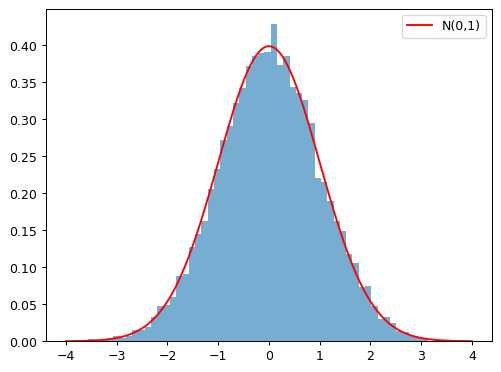

In [26]:
# Deux U indépendants produisent une paire de normales indépendantes.
U1=rng.random(N);U2=rng.random(N)
radius=np.sqrt(-2*np.log(U1));theta=2*np.pi*U2
normal_pair=np.column_stack((radius*np.cos(theta),radius*np.sin(theta)))
Z=normal_pair[:,0]
fig,ax=plt.subplots();ax.hist(Z,bins=60,density=True,alpha=.6);t=np.linspace(-4,4,300);ax.plot(t,ss.norm.pdf(t),'r',label='N(0,1)');ax.legend();plt.show()
print('Moyennes, covariance empiriques :',np.round(normal_pair.mean(axis=0),3),np.round(np.cov(normal_pair,rowvar=False),3))

**Q3**. À partir de $N$ échantillons de loi $\mathcal{N}(0,1)$, comment obtenir un $N$ échantillons de loi $\mathcal{N}(\mu, \sigma^2)$ ?

**Justification.** Si $Z\sim\mathcal N(0,1)$, alors $\mu+\sigma Z\sim\mathcal N(\mu,\sigma^2)$ pour $\sigma>0$.

Moyenne/variance empiriques : 3.0374456535035375 4.034370060891539 ; attendues : 3.0 4.0


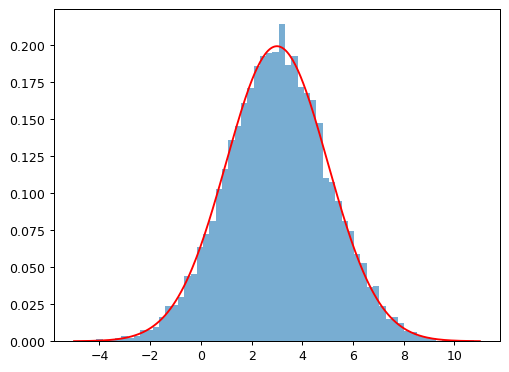

In [29]:
mu,sigma=3.0,2.0
normal_shifted=mu+sigma*Z
fig,ax=plt.subplots();ax.hist(normal_shifted,bins=60,density=True,alpha=.6);t=np.linspace(-5,11,300);ax.plot(t,ss.norm.pdf(t,loc=mu,scale=sigma),'r');plt.show()
print('Moyenne/variance empiriques :',normal_shifted.mean(),normal_shifted.var(),'; attendues :',mu,sigma**2)

**Q4**. On s'intéresse maintenant à la simulation d'un **vecteur** gaussien en dimension $d$.

Expliquer pourquoi la méthode de Box-Müller permet de simuler des vecteurs de loi $\mathcal{N_d}(\mathbf{0}_d, I_d)$.

Soit $X \sim \mathcal{N_d}(\mathbf{0}_d, I_d)$, $\mathbf{m} \in \mathbb{R}^d$, et $\boldsymbol{\Sigma} \in \mathbb{R}^{d \times d}$ symétrique définie positive. On suppose qu'il existe $\mathbf{L} \in \mathbb{R}^{d \times d}$ tel que $\boldsymbol{\Sigma} = \mathbf{L} \mathbf{L}^{\top}$.

À l'aide des propriétés des vecteurs gaussiens, montrer que $Y = \mathbf{m} + \mathbf{L}X \sim \mathcal{N_d}(\mathbf{m}, \boldsymbol{\Sigma})$.

**Justification.** Des paires Box–Müller construites avec des uniformes indépendantes fournissent autant de coordonnées normales indépendantes que nécessaire. Pour $X\sim\mathcal N_d(0,I_d)$, l’application affine $Y=m+LX$ est gaussienne, avec $E[Y]=m$ et $\mathrm{Cov}(Y)=LI_dL^\top=\Sigma$.

**Q5**. On peut montrer qu'une telle matrice $\mathbf{L}$ existe toujours. C'est la **décomposition de Cholesky** ($\mathbf{L}$ est triangulaire inférieure), qui est fondamentale en statistique et *machine learning*. Elle tire son nom d'André-Louis Cholesky, ingénieur polytechnicien, mort pendant la première guerre mondiale (résultat publié de manière posthume en 1924). À noter que la complexité associée à cette décomposition est $\mathcal{O}(d^3)$ !

À partir de $N$ échantillons de loi $\mathcal{N_d}(\mathbf{0}_d, I_d)$, générer $N$ échantillons de loi $\mathcal{N_d}(\mathbf{m}, \boldsymbol{\Sigma})$. Prendre $d=2$ et utiliser `np.linalg.cholesky`.

Moyenne empirique : [ 1.026 -1.997] théorique : [ 1. -2.]
Covariance empirique :
 [[2.017 0.786]
 [0.786 0.994]] 
Théorique :
 [[2.  0.8]
 [0.8 1. ]]


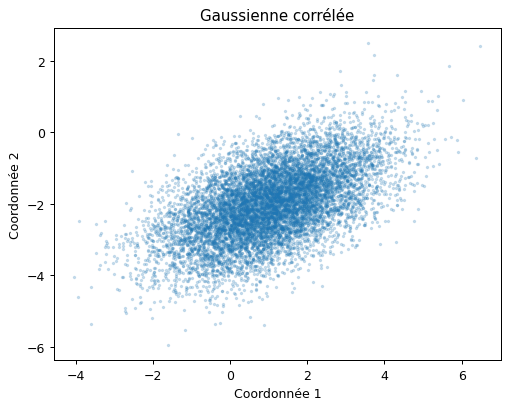

In [33]:
m=np.array([1.,-2.]);Sigma=np.array([[2.,.8],[.8,1.]])
L=np.linalg.cholesky(Sigma)
gaussian_vectors=m+normal_pair@L.T
fig,ax=plt.subplots();ax.scatter(*gaussian_vectors.T,s=3,alpha=.2);ax.set(xlabel='Coordonnée 1',ylabel='Coordonnée 2',title='Gaussienne corrélée');plt.show()
print('Moyenne empirique :',np.round(gaussian_vectors.mean(axis=0),3),'théorique :',m)
print('Covariance empirique :\n',np.round(np.cov(gaussian_vectors,rowvar=False),3),'\nThéorique :\n',Sigma)

### Exercice 4 - Acceptation-Rejet (*Rejection sampling*)

**Q1**. On considère la loi Bêta, dont la densité sur $[0,1]$ est
$$f(x;\alpha, \beta) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha) \Gamma(\beta)} x^{\alpha-1} (1-x)^{\beta-1} \quad \alpha > 0, \quad \beta > 0.$$

On souhaite obtenir des échantillons de la loi Bêta dans le cas suivant : $\alpha = 2, \beta = 2$.
* Expliquer pourquoi il est difficile de mettre en place la méthode de la transformée inverse.
* Quelle loi très simple peut-on utiliser comme loi instrumentale ?
* Implémenter alors un algorithme acceptation-rejet pour obtenir $N = 10000$ échantillons.
* Comparer la proportion empirique d'échantillons acceptés avec sa valeur théorique.
* Quelle difficulté rencontre-t-on pour le cas $\alpha = \beta = 0.5$ ?

**Justification.** La CDF de Beta(2,2) est $3x^2-2x^3$ ; son inverse demande de résoudre un polynôme cubique, moins simple que l’acceptation-rejet. Prendre $g=\mathcal U[0,1]$, $M=\sup f/g=3/2$, accepter $x$ avec probabilité $f(x)/(Mg(x))=4x(1-x)$ ; la probabilité théorique vaut $1/M=2/3$. Pour Beta(1/2,1/2), la densité diverge aux bords : aucun majorant fini $M$ n’existe avec une proposition uniforme.

**Résultat.** Le taux observé est 0,664 contre 0,667 attendu ; la moyenne des échantillons est 0,497, proche de la moyenne théorique 0,5.


Acceptés dans les lots / total proposé : 0.6638666666666667 ; théorie : 0.6666666666666666
Moyenne échantillonnée : 0.49712005942504967


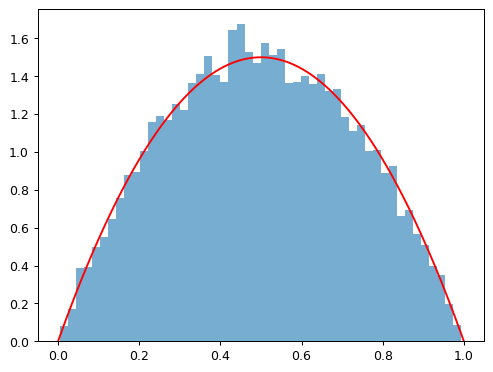

In [37]:
# f(x)=6x(1-x), g(x)=1 sur [0,1], M=sup f/g=3/2.
M=1.5;accepted=[];total=0
while len(accepted)<N:
    proposals=rng.random(15000);height=rng.random(15000)
    mask=height<=4*proposals*(1-proposals)  # f/(M*g)=6x(1-x)/1.5.
    accepted.extend(proposals[mask]);total+=len(proposals)
beta_samples=np.array(accepted[:N])
fig,ax=plt.subplots();ax.hist(beta_samples,bins=50,density=True,alpha=.6);t=np.linspace(0,1,300);ax.plot(t,ss.beta.pdf(t,2,2),'r');plt.show()
print('Acceptés dans les lots / total proposé :',len(accepted)/total,'; théorie :',1/M)
print('Moyenne échantillonnée :',beta_samples.mean())

**Q2**. On souhaite maintenant obtenir des échantillons d'une loi gaussienne tronquée, i.e., une loi normale restreinte à un certain intervalle (en 1D), ou un certain pavé de l'espace (pour le cas multivarié).

On considère le cas d'une gaussienne multivariée $\mathcal{N}_d(0, I_d)$ que l'on tronque sur le pavé $[-1,2]^d$. On prendra comme loi instrumentale la loi $\mathcal{N}(0, I_d)$ (i.e., non tronquée)

* Justifier ce choix de loi instrumentale.
* Pour le cas univarié ($d=1$), calculer numériquement la probabilité d'acceptation de l'algorithme acceptation-rejet. On pourra utiliser `scipy.stats.cdf`.
* Que devient cette probabilité pour $d=10$ ? $d=100$ ? Conclure quant à la faiblesse fondamentale de l'algorithme acceptation-rejet.

**Justification.** Proposer directement $Z\sim\mathcal N_d(0,I_d)$ puis garder uniquement $Z\in[-1,2]^d$ produit la loi tronquée voulue. Avec $p=\Phi(2)-\Phi(-1)$, l’acceptation vaut $p^d$ car les coordonnées sont indépendantes. En grande dimension, elle devient minuscule : la méthode gaspille presque tous les tirages.

**Résultat.** L’acceptation vaut environ 0,819 en dimension 1, 0,135 en dimension 10 et 2,03 × 10⁻⁹ en dimension 100 : ce dernier cas exige en moyenne près de 493 millions de propositions par tirage accepté.


In [40]:
p1=ss.norm.cdf(2)-ss.norm.cdf(-1)
for d in (1,10,100):print(f'd={d}: probabilité acceptée={p1**d:.5g}, essais moyens={1/p1**d:.5g}')
# La loi conditionnelle peut se simuler en conservant uniquement les tirages du pavé.
candidates=rng.normal(size=(30000,2));inside=np.all((-1<=candidates)&(candidates<=2),axis=1)
print('Taux empirique d=2 :',inside.mean(),'; taux théorique :',p1**2)

d=1: probabilité acceptée=0.81859, essais moyens=1.2216
d=10: probabilité acceptée=0.13511, essais moyens=7.4014
d=100: probabilité acceptée=2.0272e-09, essais moyens=4.933e+08
Taux empirique d=2 : 0.6728 ; taux théorique : 0.6700971422668672


### Exercice 5 - Estimation de $\pi$ par Monte Carlo

On rappelle que $\pi$ est égal à la surface d'un cercle de rayon 1, i.e.
$$ \pi = \int_{-1}^1 \int_{-1}^1 \mathbb{1}_{x^2 + y^2 \leq 1}(x,y) dx dy.$$

Ce qui peut se réécrire comme
$$ \pi = 4 \int_{-1}^1 \int_{-1}^1 \mathbb{1}_{x^2 + y^2 \leq 1}(x,y) p(x) p(y) dx dy.$$
Où $p(x)$ et $p(y)$ sont les densités de la loi uniforme sur $[-1,1]$.

* En déduire l'esimtateur de Monte Carlo de $\pi$.
* Générer $N_s = 10000$ échantillons, puis représenter l'évolution de la valeur de l'estimation par Monte Carlo de $\pi$ en ne gardant que les $N$ premiers. Quel résultat fondamental est-on en train d'illustrer ?
* Faire 1000 simulations de l'estimation par Monte Carlo de $\pi$ avec $N_s = 10000$ échantillons, et vérifier le résultat de convergence en loi de l'estimateur de Monte Carlo donné par le TCL.

**Justification.** Pour $(X_i,Y_i)$ indépendants uniformes sur $[-1,1]^2$, $\hat\pi_N=4N^{-1}\sum_i\mathbf 1_{X_i^2+Y_i^2\le1}$. La loi des grands nombres assure $\hat\pi_N\to\pi$ ; le TCL donne approximativement une loi normale de moyenne $\pi$ et variance $16(\pi/4)(1-\pi/4)/N$.

**Résultat.** Sur 1000 répétitions, la moyenne des estimations vaut 3,1407 et leur écart-type 0,01657, proche de 0,01642 prédit par le TCL.


Moyenne/sd empirique : 3.1407216 0.016567240171099312 ; sd TCL : 0.01642183367736324


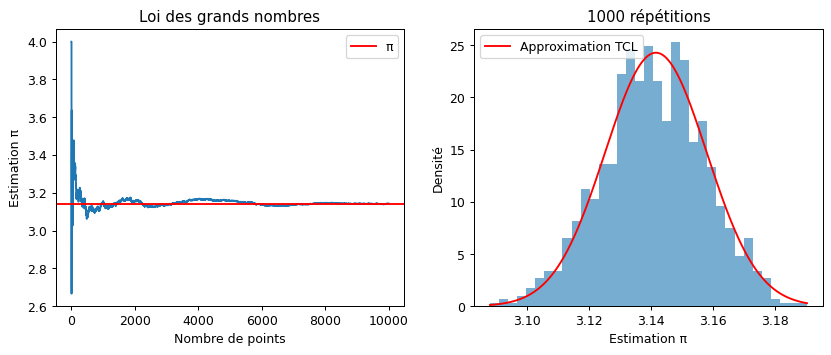

In [43]:
Ns=10000;xy=rng.uniform(-1,1,size=(Ns,2));inside=(xy**2).sum(axis=1)<=1
running=4*np.cumsum(inside)/np.arange(1,Ns+1)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(running);axes[0].axhline(np.pi,c='r',label='π');axes[0].set(xlabel='Nombre de points',ylabel='Estimation π',title='Loi des grands nombres');axes[0].legend()
repetitions=1000;estimates=np.empty(repetitions)
for i in range(repetitions):
    pts=rng.uniform(-1,1,size=(Ns,2));estimates[i]=4*np.mean((pts**2).sum(axis=1)<=1)
# TCL : écart type théorique de 4*Bernoulli(p), p=π/4.
theoretical_sd=4*np.sqrt((np.pi/4)*(1-np.pi/4)/Ns)
t=np.linspace(estimates.min(),estimates.max(),300)
axes[1].hist(estimates,bins=35,density=True,alpha=.6);axes[1].plot(t,ss.norm.pdf(t,np.pi,theoretical_sd),'r',label='Approximation TCL')
axes[1].set(xlabel='Estimation π',ylabel='Densité',title='1000 répétitions');axes[1].legend();plt.show()
print('Moyenne/sd empirique :',estimates.mean(),estimates.std(ddof=1),'; sd TCL :',theoretical_sd)

### Exercice 6 - Échantillonnage d'importance (*Importance sampling*)

On cherche à estimer $\mathbb{P}(X > 3)$ avec $X \sim \mathcal{N}(0,1)$.

* Ré-écrire cette probabilité comme une intégrale et en déduire l'estimateur de Monte Carlo "standard".
* Simuler $1000$ fois $N_s = 10000$ échantillons, et calculer la moyenne et la variance empiriques de l'estimateur de Monte Carlo standard.
* On souhaite maintenant implémenter un schéma d'échantillonnage d'importance en utilisant comme loi instrumentale $\mathcal{N}(4,1)$. Donner l'estimateur de Monte Carlo associé.
* De même, simuler $1000$ fois $N_s = 10000$ échantillons, et calculer la moyenne et la variance empiriques de de deuxième estimateur.
* Quantifier la réduction de variance. Commenter.

**Justification.** La probabilité cherchée est $\int_3^\infty\phi(x)dx$. En MC standard : moyenne des $\mathbf 1_{X_i>3}$ avec $X_i\sim\phi$. Avec $Z_i\sim g=\mathcal N(4,1)$ : moyenne de $\mathbf 1_{Z_i>3}\phi(Z_i)/g(Z_i)$. Les poids corrigent le changement de loi ; la concentration des tirages dans la zone rare peut réduire la variance.

**Résultat.** Les deux moyennes sont proches de la vraie valeur 0,0013499. La variance empirique passe de 1,29 × 10⁻⁷ à 9,32 × 10⁻¹⁰, soit une réduction d’environ **139 fois**.


Vérité : 0.0013498980316300933
MC standard : moyenne 0.0013540999999999998 variance 1.2945264264264264e-07
Importance : moyenne 0.0013507442151562627 variance 9.315779771321513e-10
Facteur de réduction de variance : 138.96060858068012


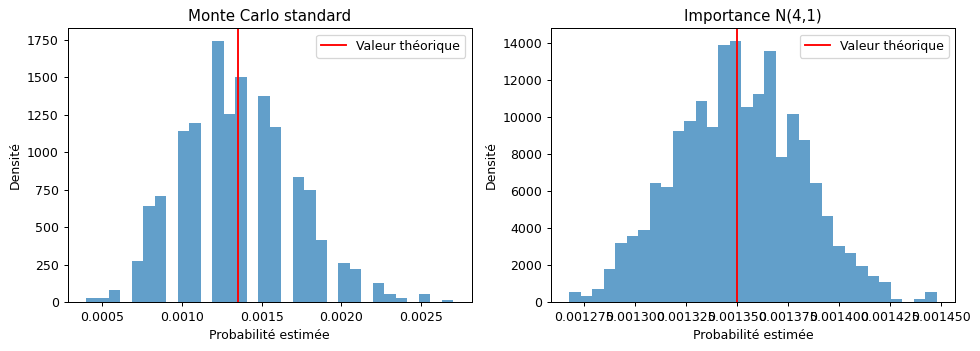

In [47]:
Ns=10000;repetitions=1000
standard=np.empty(repetitions);importance=np.empty(repetitions)
for i in range(repetitions):
    x=rng.normal(size=Ns);standard[i]=np.mean(x>3)
    z=rng.normal(loc=4,size=Ns)
    weights=np.exp(ss.norm.logpdf(z)-ss.norm.logpdf(z,loc=4))
    importance[i]=np.mean((z>3)*weights)
truth=ss.norm.sf(3)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,s,title in zip(axes,(standard,importance),('Monte Carlo standard','Importance N(4,1)')):
    ax.hist(s,bins=32,density=True,alpha=.7);ax.axvline(truth,color='r',label='Valeur théorique');ax.set(xlabel='Probabilité estimée',ylabel='Densité',title=title);ax.legend()
fig.tight_layout();plt.show()
print('Vérité :',truth)
print('MC standard : moyenne',standard.mean(),'variance',standard.var(ddof=1))
print('Importance : moyenne',importance.mean(),'variance',importance.var(ddof=1))
print('Facteur de réduction de variance :',standard.var(ddof=1)/importance.var(ddof=1))